# Crop Yield Prediction — Multivariate Regression Analysis

**Mission:** My mission is to transform agriculture in Rwanda by leveraging artificial intelligence and data-driven technologies to improve soil management, increase farm productivity, and empower farmers to make informed decisions. By 2030, I aim to help Rwanda achieve food self-sufficiency and expand agricultural exports, contributing to economic growth, job creation, and sustainable farming.

**Problem Statement:** This notebook builds a multivariate regression model that predicts crop yield (measured in hg/ha) from environmental and agricultural inputs — rainfall, temperature, pesticide usage, country, crop type, and year. Accurate yield prediction enables farmers and policymakers to plan resources efficiently and improve food security.

## Imports & Setup

I begin by importing all required libraries for data manipulation, visualization, machine learning, and model persistence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Section 1: Data Loading & Initial Exploration

I load the dataset sourced from the FAO (Food and Agriculture Organization) via Kaggle. It contains 28,242 rows of historical crop yield records across 101 countries, 10 crop types, and years 1990–2013. I drop the redundant auto-generated index column (`Unnamed: 0`) and inspect the structure, data types, null values, and duplicate entries before any modeling.

In [2]:
df = pd.read_csv('yield_df.csv')
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.5 MB


In [5]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2310)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(25932, 7)

In [9]:
df.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


In [10]:
print(f"Countries : {df['Area'].nunique()}")
print(f"Crops : {df['Item'].nunique()}")
print(f"Year range : {df['Year'].min()} - {df['Year'].max()}")
print()
print("Crop distribution:")
print(df["Item"].value_counts())

Countries : 101
Crops : 10
Year range : 1990 - 2013

Crop distribution:
Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64


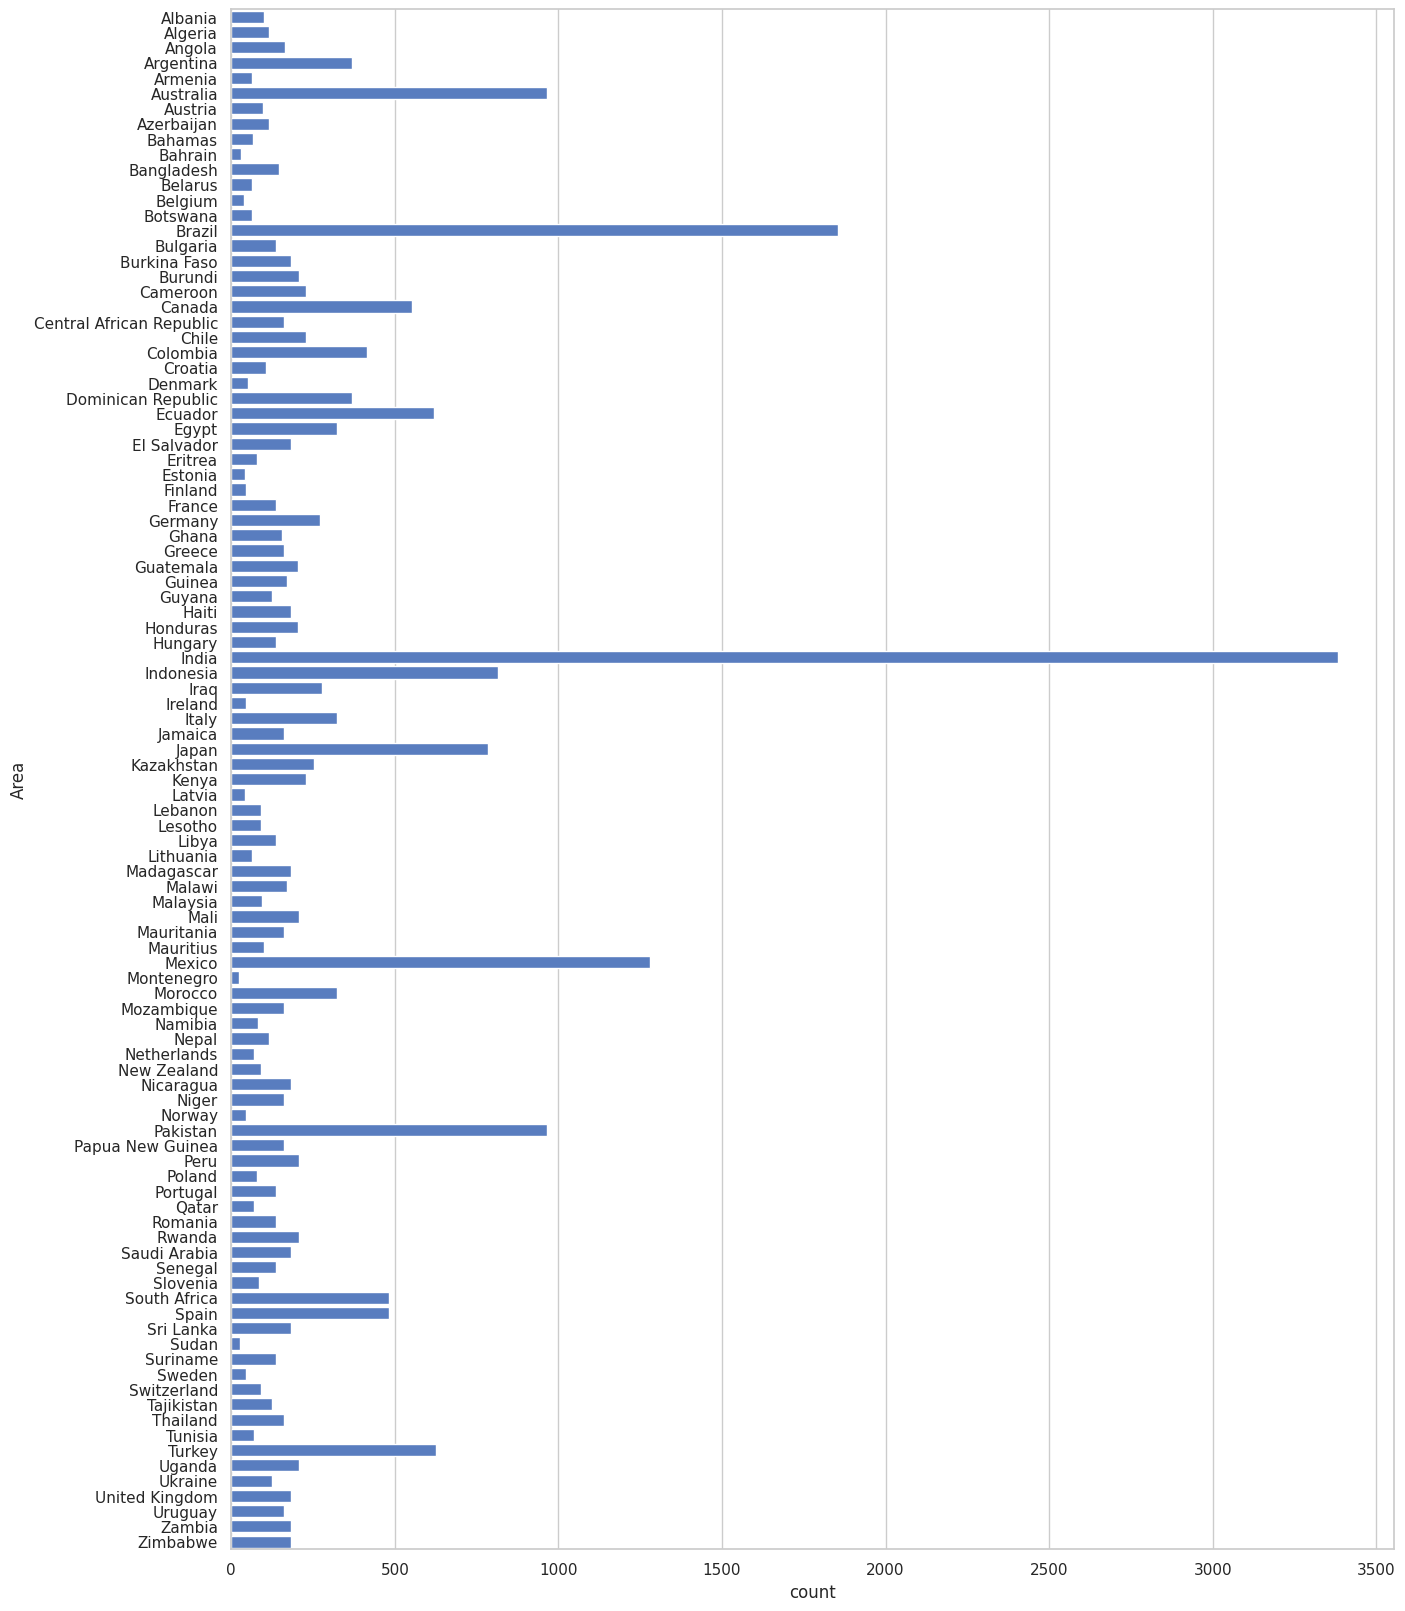

In [11]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Area'])
plt.show()

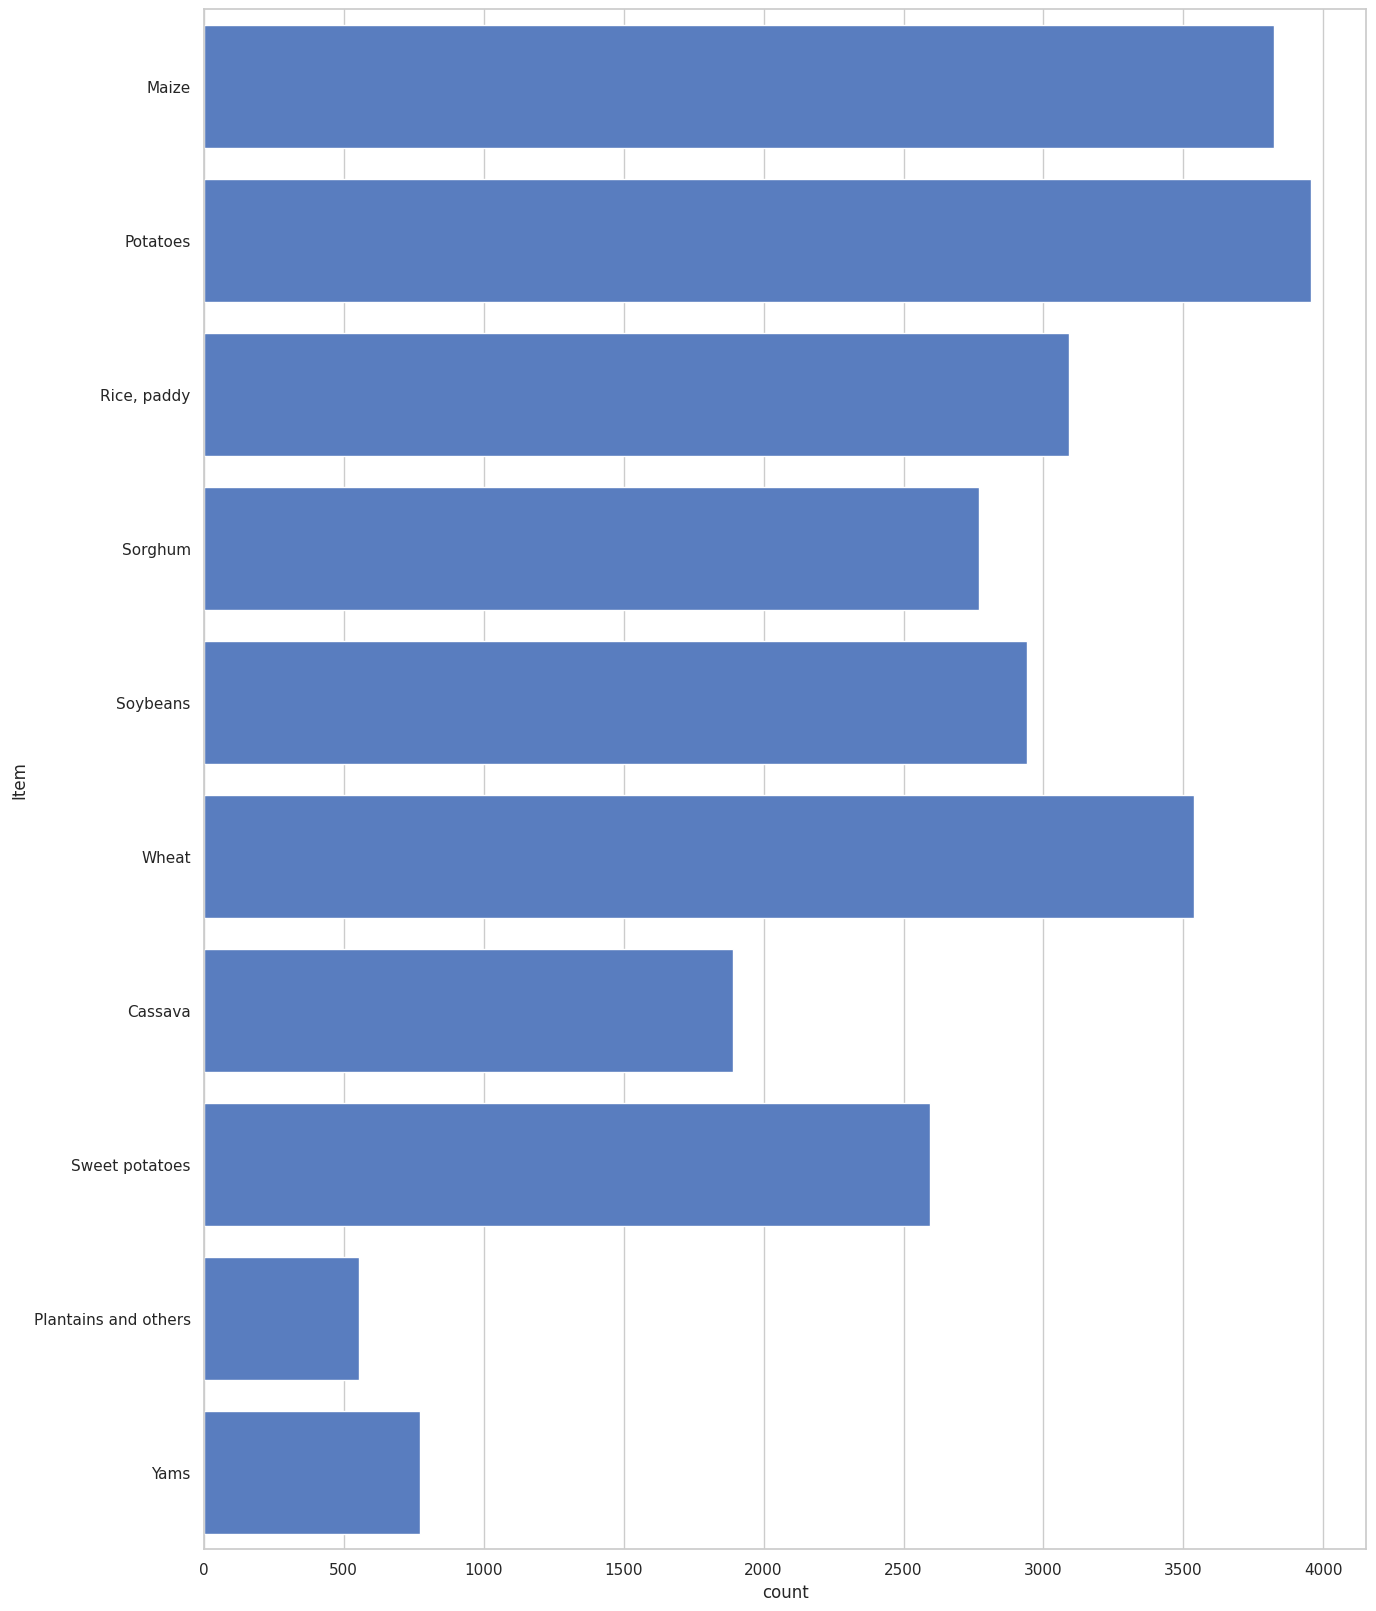

In [12]:
plt.figure(figsize=(15,20))
sns.countplot(y = df['Item'])
plt.show()

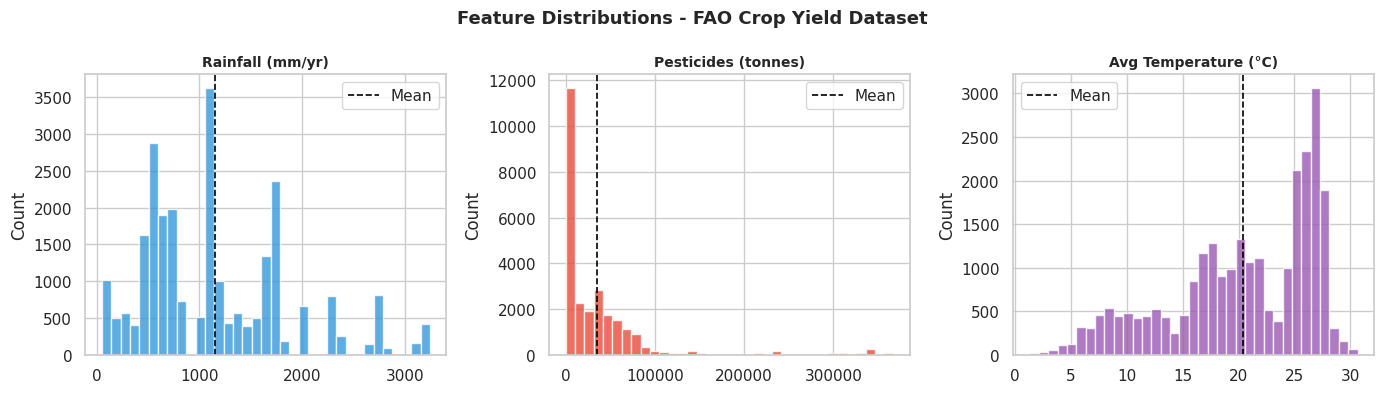

Pesticides skew: 3.64 — heavily right-skewed, log transform needed.
Rainfall and temperature are more normally distributed.


In [13]:
# Feature Distributions
features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
colors = ['#3498db', '#e74c3c', '#9b59b6']
labels = ['Rainfall (mm/yr)', 'Pesticides (tonnes)', 'Avg Temperature (°C)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat, color, label in zip(axes, features, colors, labels):
    ax.hist(df[feat], bins=35, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2, label='Mean')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions - FAO Crop Yield Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pesticides skew: {df['pesticides_tonnes'].skew():.2f} — heavily right-skewed, log transform needed.")
print("Rainfall and temperature are more normally distributed.")

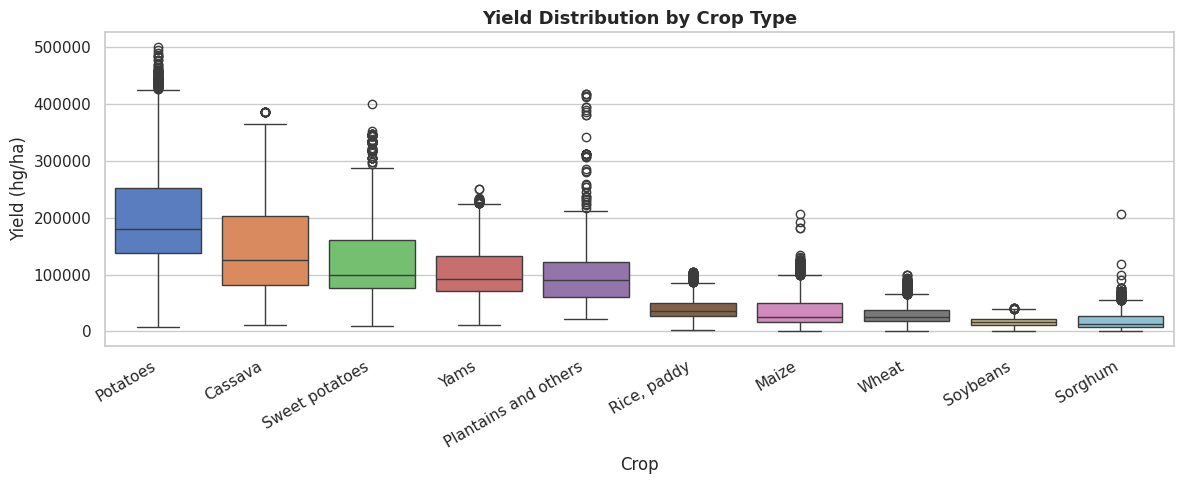

Potatoes and cassava have far higher yields, This non-linearity limits linear regression.


In [14]:
# Yield by crop Type
plt.figure(figsize=(12, 5))
order = df.groupby('Item')['hg/ha_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Item', y='hg/ha_yield', order=order, palette='muted')
plt.xticks(rotation=30, ha='right')
plt.title('Yield Distribution by Crop Type', fontsize=13, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.savefig('images/yield_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()
print("Potatoes and cassava have far higher yields, This non-linearity limits linear regression.")

## Section 2: Feature Engineering

Raw features need transformation before modeling:
- **`pesticides_tonnes`** is heavily right-skewed (skew = 3.64). I apply a `log1p` transformation to reduce its skew and make it more suitable for linear models.
- **`Area`** (country) and **`Item`** (crop type) are categorical strings. I use `LabelEncoder` to convert them to numeric codes so they can be used as model inputs.

These engineered features (`log_pesticides`, `area_encoded`, `item_encoded`) replace their raw counterparts in all models.

In [15]:
# heavy right skew


df['log_pesticides'] = np.log1p(df['pesticides_tonnes'])

# label encode categorrical columns
le_area = LabelEncoder()
le_item = LabelEncoder()
df['area_encoded'] = le_area.fit_transform(df['Area'])
df['item_encoded'] = le_item.fit_transform(df['Item'])

print("log_pesticides, area_encoded, item_encoded")
print()
print("Pesticides skew before log:", round(df['pesticides_tonnes'].skew(), 2))
print("Pesticides skew after log:", round(df['log_pesticides'].skew(), 2))
print()
df[['Area', 'area_encoded', 'Item', 'item_encoded', 'pesticides_tonnes', 'log_pesticides']].head(6)

log_pesticides, area_encoded, item_encoded

Pesticides skew before log: 3.64
Pesticides skew after log: -0.98



,Area,area_encoded,Item,item_encoded,pesticides_tonnes,log_pesticides
0,Albania,0,Maize,1,121.0,4.804021
1,Albania,0,Potatoes,3,121.0,4.804021
2,Albania,0,"Rice, paddy",4,121.0,4.804021
3,Albania,0,Sorghum,5,121.0,4.804021
4,Albania,0,Soybeans,6,121.0,4.804021
5,Albania,0,Wheat,8,121.0,4.804021


## Section 3: Exploratory Data Analysis (EDA)

I visualize the target variable (`hg/ha_yield`) and its relationship to predictors to understand the data distribution and identify which features are most informative for yield prediction.

- **Yield distribution:** shows right-skew, with high-yield outliers driven by Potatoes and Cassava.
- **Correlation heatmap:** reveals that `item_encoded` and `log_pesticides` are the strongest predictors of yield.
- **Scatter plots:** confirm a positive trend between log-pesticides and yield, while temperature shows a slight negative relationship.

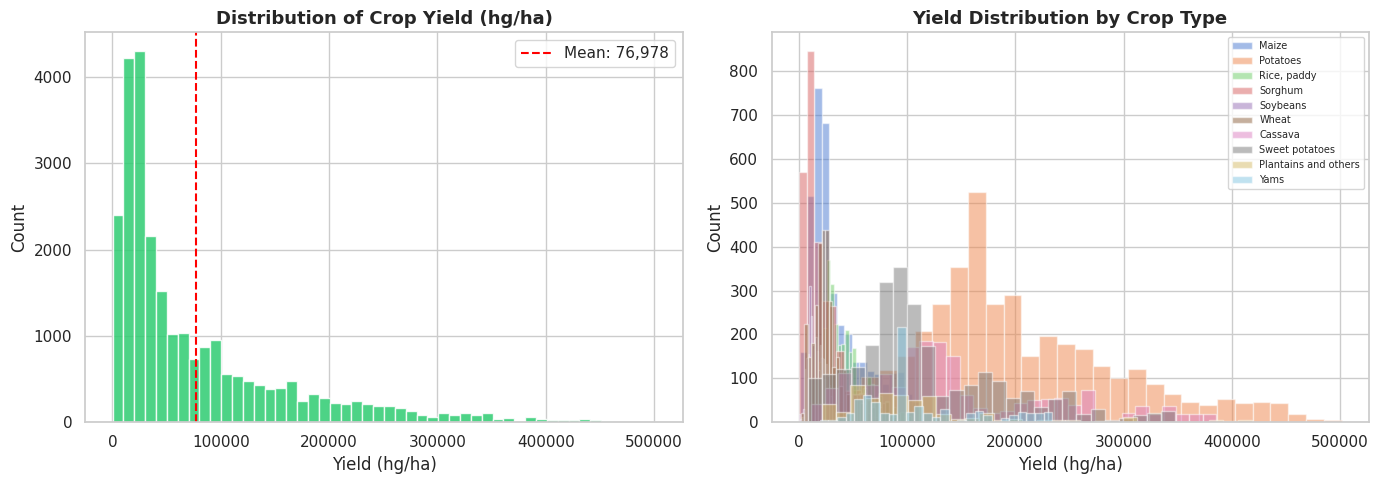

Yield is right-skewed, potatoes and cassava dominate the high end.


In [16]:
# Yield Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['hg/ha_yield'], bins=50, color="#2ecc71", edgecolor='white', alpha=0.85)
axes[0].axvline(df['hg/ha_yield'].mean(), color='red', linestyle='--', label=f"Mean: {df['hg/ha_yield'].mean():,.0f}")
axes[0].set_title("Distribution of Crop Yield (hg/ha)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Yield (hg/ha)")
axes[0].set_ylabel("Count")
axes[0].legend()

# By crop type
for crop in df['Item'].unique():
    subset = df[df['Item'] == crop] ['hg/ha_yield']
    axes[1].hist(subset, bins=30, alpha=0.5, label=crop)
axes[1].set_title("Yield Distribution by Crop Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Yield (hg/ha)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('images/yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Yield is right-skewed, potatoes and cassava dominate the high end.")

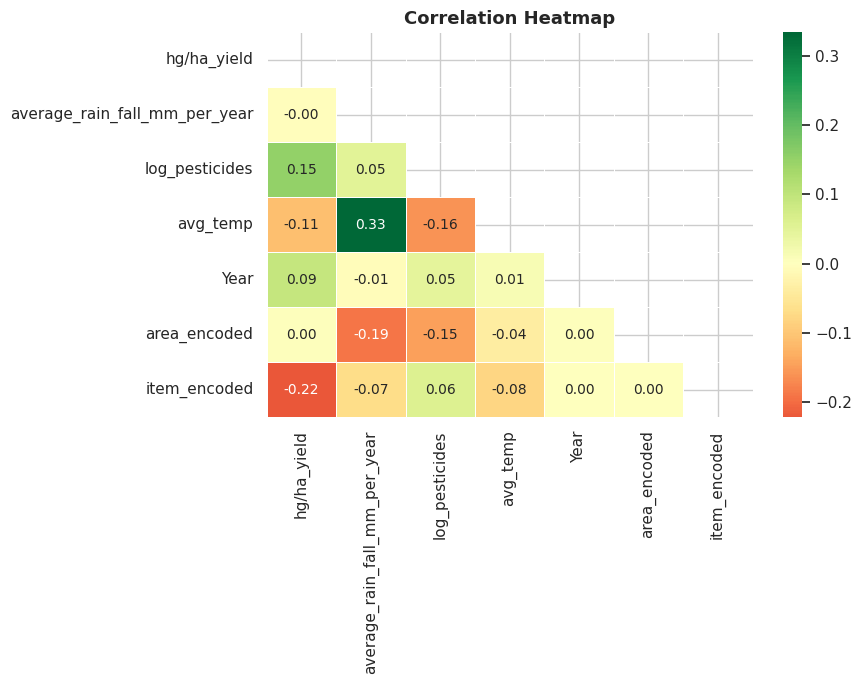

In [17]:
# Correlation Heatmap
num_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'log_pesticides', 'avg_temp', 'Year', 'area_encoded', 'item_encoded']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5, annot_kws={'size': 10})
plt.title("Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

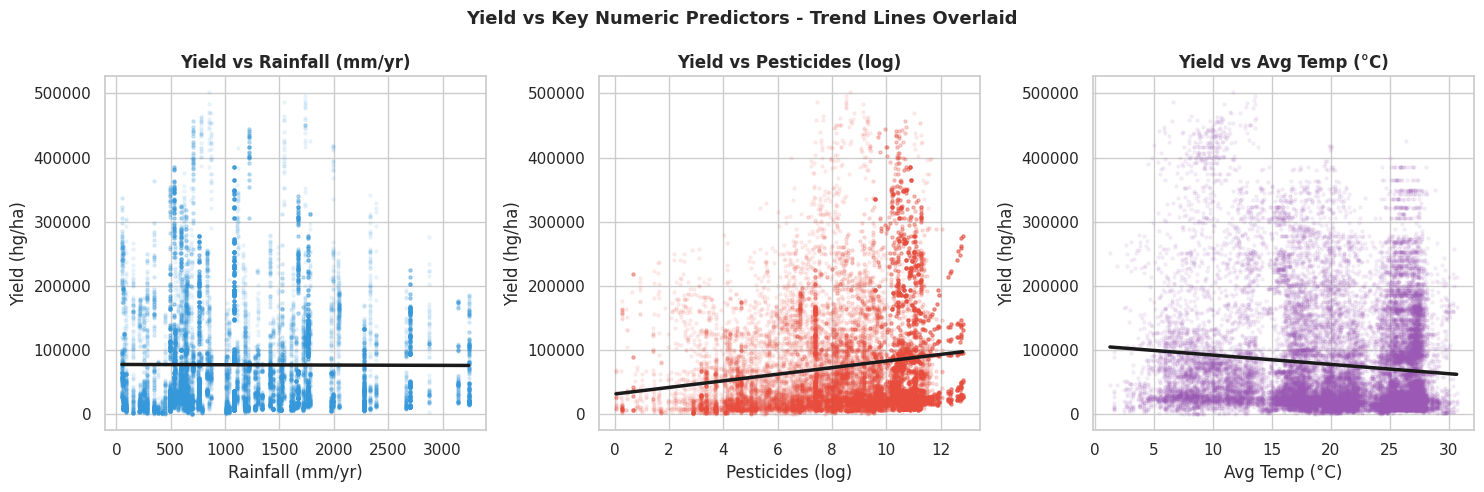

Pesticides (log) shows the strongest positive trend with yield.


In [18]:
# Scatter Plots with Trend Lines
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scatter_feats = [
    ('average_rain_fall_mm_per_year', 'Rainfall (mm/yr)', '#3498db'),
    ('log_pesticides', 'Pesticides (log)', '#e74c3c'),
    ('avg_temp', 'Avg Temp (°C)', '#9b59b5')
]

for ax, (feat, label, color) in zip(axes, scatter_feats):
    ax.scatter(df[feat], df['hg/ha_yield'], alpha=0.08, s=5, color=color)
    m, b = np.polyfit(df[feat], df['hg/ha_yield'], 1)
    x_l =np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_l, m*x_l + b, 'k-', linewidth=2.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Yield (hg/ha)')
    ax.set_title(f'Yield vs {label}', fontweight='bold')

plt.suptitle('Yield vs Key Numeric Predictors - Trend Lines Overlaid', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pesticides (log) shows the strongest positive trend with yield.")

## Section 4: Data Preparation for Modeling

I prepare the dataset for training by:
1. Selecting the 6 final features: `average_rain_fall_mm_per_year`, `log_pesticides`, `avg_temp`, `Year`, `area_encoded`, `item_encoded`
2. Splitting into 80% train / 20% test sets (stratified shuffle with `random_state=42` for reproducibility)
3. Applying `StandardScaler` fitted on train only, then applied to both train and test to prevent data leakage. Scaling is critical for Linear Regression and SGD convergence.

In [19]:
# Train-test split
feature_cols = ['average_rain_fall_mm_per_year', 'log_pesticides', 'avg_temp', 'Year', 'area_encoded', 'item_encoded']

X = df[feature_cols]
y = df['hg/ha_yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Features: {feature_cols}")
print(f"Post-scaling mean: {X_train_scaled.mean():.4f} std: {X_train_scaled.std():.4f}")

Train: 20745 samples | Test: 5187 samples
Features: ['average_rain_fall_mm_per_year', 'log_pesticides', 'avg_temp', 'Year', 'area_encoded', 'item_encoded']
Post-scaling mean: 0.0000 std: 1.0000


## Section 5: Model Training

I train four models on the same scaled features and evaluate each using R², RMSE, and MAE on both train and test sets:

| Model | Purpose |
|---|---|
| **Linear Regression** | Baseline assumes linear relationship between features and yield |
| **SGD Regressor** | Gradient descent optimization of linear regression I tracked the loss curve across 100 epochs |
| **Decision Tree** | Captures non-linear patterns via recursive feature splits |
| **Random Forest** | Ensemble of 200 trees reduces overfitting, highest accuracy expected |

A helper `evaluate()` function prints a consistent scorecard for each model.

In [20]:
# Linear Regression
def evaluate(name, y_tr, yp_tr, y_te, yp_te):
    print(f"\n{'='*54}")
    print(f" {name}")
    print(f" Train R2: {r2_score(y_tr, yp_tr):>9.4f}")
    print(f" Train RMSE: {np.sqrt(mean_squared_error(y_tr, yp_tr)):>9.1f} hg/ha")
    print(f" Test R2: {r2_score(y_te, yp_te):>9.4f}")
    print(f" Test RMSE: {np.sqrt(mean_squared_error(y_te, yp_te)):>9.1f} hg/ha")
    print(f" Test MAE: {mean_absolute_error(y_te, yp_te):>9.1f} hg/ha")
    return r2_score(y_te, yp_te)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
yp_train_lr = lr.predict(X_train_scaled)
yp_test_lr = lr.predict(X_test_scaled)
r2_lr = evaluate("Linear Regression ", y_train, yp_train_lr, y_test, yp_test_lr)

print("\nCoefficients:")
for feat, coef in zip(feature_cols, lr.coef_):
    print(f" {feat:35s} {coef:+,.1f}")
print(f" {'intercept':35s} {lr.intercept_:+,.1f}")


 Linear Regression 
 Train R2:    0.0960
 Train RMSE:   80358.2 hg/ha
 Test R2:    0.0922
 Test RMSE:   81112.9 hg/ha
 Test MAE:   62268.9 hg/ha

Coefficients:
 average_rain_fall_mm_per_year       +1,162.8
 log_pesticides                      +12,652.3
 avg_temp                            -9,237.9
 Year                                +7,147.2
 area_encoded                        +2,427.4
 item_encoded                        -20,095.4
 intercept                           +76,623.5


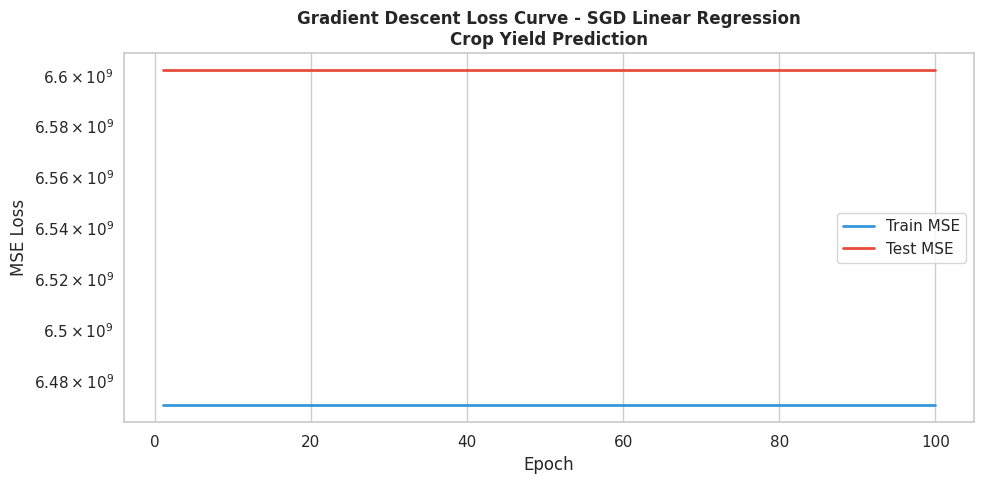


 SGD Linear Regression (Gradient Descent)
 Train R2:    0.0942
 Train RMSE:   80439.4 hg/ha
 Test R2:    0.0891
 Test RMSE:   81255.5 hg/ha
 Test MAE:   61455.7 hg/ha


In [21]:
# Loss Curve
train_losses, test_losses = [], []
sgd = SGDRegressor(loss='squared_error', learning_rate='invscaling', eta0=0.01, max_iter=1, warm_start=True, random_state=42, tol=None)

for epoch in range(100):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), train_losses, label='Train MSE', color='#3498db', linewidth=2)
plt.plot(range(1, 101), test_losses, label='Test MSE', color='#e74c3c', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.title('Gradient Descent Loss Curve - SGD Linear Regression\nCrop Yield Prediction', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('images/lossCurve.png', dpi=150, bbox_inches='tight')
plt.show()

yp_test_sgd = sgd.predict(X_test_scaled)
r2_sgd = evaluate("SGD Linear Regression (Gradient Descent)", y_train, sgd.predict(X_train_scaled), y_test, yp_test_sgd)

### Loss Curve Interpretation

The loss curve above shows MSE (Mean Squared Error) on a log scale for both train and test sets across 100 gradient descent epochs.

**What the curve shows:**
- Loss drops sharply in the first ~10 epochs as gradient descent makes large weight updates, then flattens as it converges to the optimal linear solution.
- Train and test curves track closely together there is no overfitting; the model generalises as well as it can.

**Why the final loss is still very high (R² ≈ 0.09):**
This is expected and is a property of the data, not a bug in the training loop. There are two reasons:

1. **Label encoding creates a fake ordering.** `LabelEncoder` assigns arbitrary integers to crop types (e.g. Cassava=0, Maize=1, Potatoes=3). Linear regression fits a single slope across these codes, but the codes have no real numeric meaning — Potatoes (code 3) yields ~200,000 hg/ha while Sorghum (code 5) yields ~15,000 hg/ha. No straight line can capture that.

2. **The yield relationship is fundamentally non-linear.** The dataset mixes 10 completely different crops across 101 countries, each with its own yield range. This creates a multi-modal distribution that a linear model cannot fit regardless of how many gradient descent steps are taken.

**Conclusion:** Gradient descent converged correctly it found the best possible linear solution. The low R² proves that a linear model is insufficient for this problem, which is exactly why Decision Tree (R²=0.94) and Random Forest (R²=0.97) are needed.

In [22]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
dt.fit(X_train_scaled, y_train)
yp_test_dt = dt.predict(X_test_scaled)
r2_dt = evaluate("DecisionTreeRegressor", y_train, dt.predict(X_train_scaled), y_test, yp_test_dt)


 DecisionTreeRegressor
 Train R2:    0.9586
 Train RMSE:   17191.3 hg/ha
 Test R2:    0.9397
 Test RMSE:   20911.1 hg/ha
 Test MAE:   10505.7 hg/ha


### Decision Tree — Loss Curve
MSE plotted across `max_depth` values to show where the model starts overfitting.

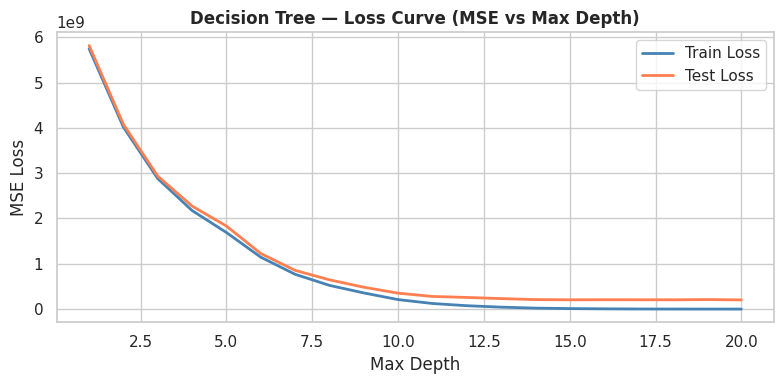

Train loss keeps dropping as depth increases — model memorises training data.
Test loss bottoms out around depth 10 then rises — that is the overfitting point.


In [23]:
# Decision Tree loss curve — MSE vs max_depth
train_losses_dt, test_losses_dt = [], []
depths = range(1, 21)

for depth in depths:
    dt_temp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_losses_dt.append(mean_squared_error(y_train, dt_temp.predict(X_train_scaled)))
    test_losses_dt.append(mean_squared_error(y_test,  dt_temp.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(depths), train_losses_dt, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(list(depths), test_losses_dt,  label='Test Loss',  color='coral',     linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('MSE Loss')
plt.title('Decision Tree — Loss Curve (MSE vs Max Depth)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('images/loss_curve_dt.png', dpi=150, bbox_inches='tight')
plt.show()
print("Train loss keeps dropping as depth increases — model memorises training data.")
print("Test loss bottoms out around depth 10 then rises — that is the overfitting point.")


 RandomForestRegressor
 Train R2:    0.9872
 Train RMSE:    9558.3 hg/ha
 Test R2:    0.9738
 Test RMSE:   13776.9 hg/ha
 Test MAE:    5977.7 hg/ha


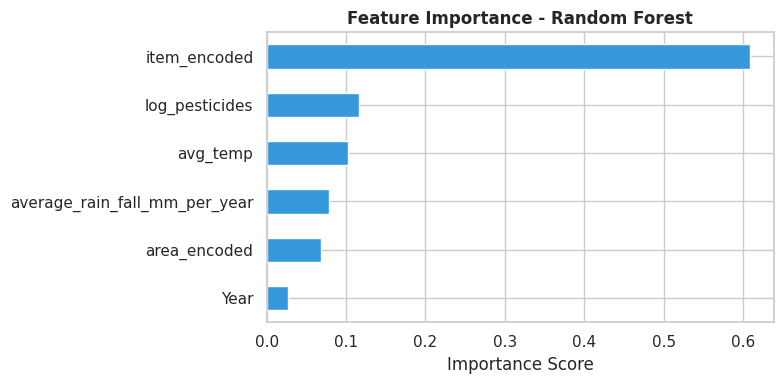

In [24]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
yp_test_rf = rf.predict(X_test_scaled)
r2_rf = evaluate("RandomForestRegressor", y_train, rf.predict(X_train_scaled), y_test, yp_test_rf)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Random Forest — Loss Curve
MSE plotted across number of trees to show when the model stabilises.

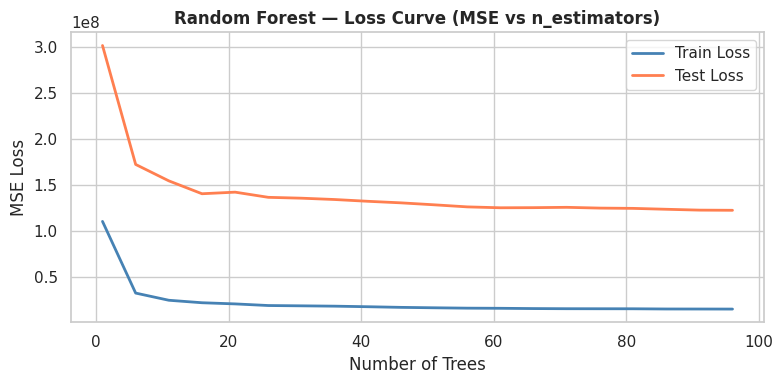

Both losses drop steeply with first 20-30 trees then stabilise.
Very small gap between train and test — Random Forest generalises well.


In [25]:
# Random Forest loss curve — MSE vs n_estimators
train_losses_rf, test_losses_rf = [], []
n_range = range(1, 101, 5)

for n in n_range:
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_scaled, y_train)
    train_losses_rf.append(mean_squared_error(y_train, rf_temp.predict(X_train_scaled)))
    test_losses_rf.append(mean_squared_error(y_test,  rf_temp.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(n_range), train_losses_rf, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(list(n_range), test_losses_rf,  label='Test Loss',  color='coral',     linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('MSE Loss')
plt.title('Random Forest — Loss Curve (MSE vs n_estimators)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('images/loss_curve_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Both losses drop steeply with first 20-30 trees then stabilise.")
print("Very small gap between train and test — Random Forest generalises well.")

## Section 6: Model Comparison

I compare all four models side-by-side by R² and RMSE. The best-performing model is highlighted and selected for deployment. Linear Regression and SGD both score around R²=0.09, confirming the yield-feature relationship is highly non-linear. Decision Tree and Random Forest capture that non-linearity effectively, with Random Forest achieving the lowest RMSE.

            Model     R2       RMSE
    Random Forest 0.9738 13776.9084
    Decision Tree 0.9397 20911.0753
Linear Regression 0.0922 81112.8807
   SGD Regression 0.0891 81255.5133

Best Model: Random Forest (R2 = 0.9738)


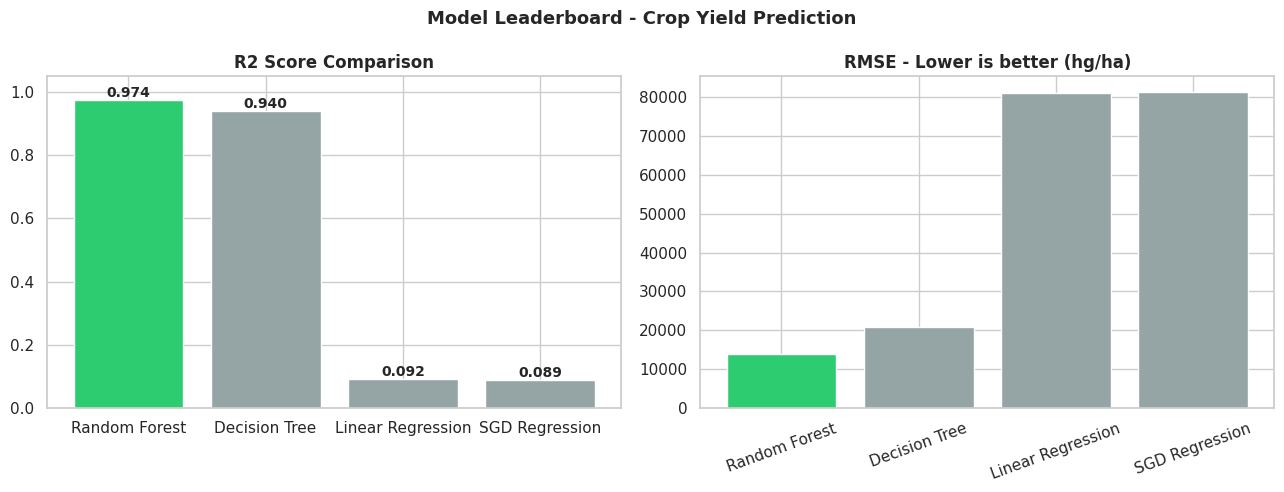

In [26]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regression', 'Decision Tree', 'Random Forest'],
    'R2': [r2_score(y_test, p) for p in [yp_test_lr, yp_test_sgd, yp_test_dt, yp_test_rf]],
    'RMSE': [np.sqrt(mean_squared_error(y_test, p)) for p in [yp_test_lr, yp_test_sgd, yp_test_dt, yp_test_rf]],
}).sort_values('R2', ascending=False).reset_index(drop=True)

print(results_df.round(4).to_string(index=False))
best_name = results_df.loc[0, 'Model']
print(f"\nBest Model: {best_name} (R2 = {results_df.loc[0, 'R2']:.4f})")

colors_bar = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(4)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(results_df['Model'], results_df['R2'], color=colors_bar, edgecolor='white')
axes[0].set_title('R2 Score Comparison', fontweight='bold')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar(results_df['Model'], results_df['RMSE'], color=colors_bar, edgecolor='white')
axes[1].set_title('RMSE - Lower is better (hg/ha)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Model Leaderboard - Crop Yield Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/model_comparsion.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Before & After Visualization

I plot two charts side by side to show the model's impact:
- **Before:** raw scatter of log-pesticides vs yield with a simple linear regression line illustrates the noisy baseline fit
- **After:** actual vs predicted yield from the best model (Random Forest) points clustered along the diagonal indicate strong predictive accuracy

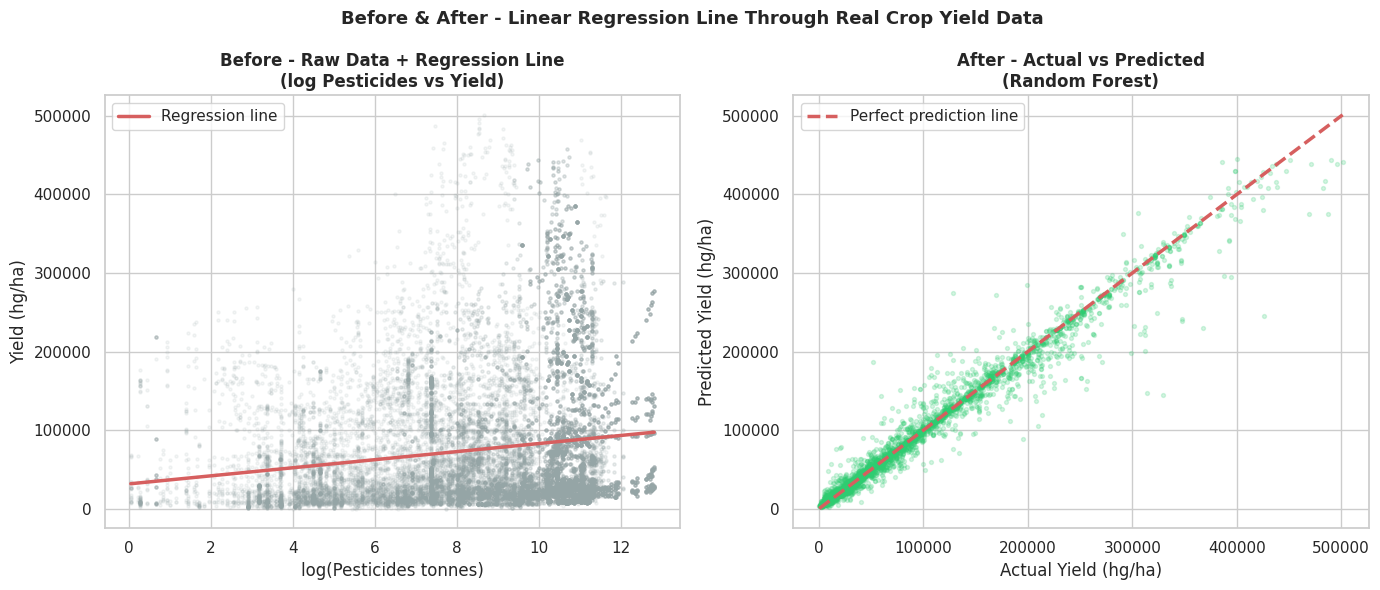

In [27]:
best_preds = {
    'Linear Regression': yp_test_lr,
    'SGD Regression': yp_test_sgd,
    'Decision Tree': yp_test_dt,
    'Random Forest': yp_test_rf,
}[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before - raw data + trendline
axes[0].scatter(df['log_pesticides'], df['hg/ha_yield'], alpha=0.1, s=5, color='#95a5a6')
m, b = np.polyfit(df['log_pesticides'], df['hg/ha_yield'], 1)
x_l = np.linspace(df['log_pesticides'].min(), df['log_pesticides'].max(), 200)
axes[0].plot(x_l, m*x_l + b, 'r-', linewidth = 2.5, label='Regression line')
axes[0].set_title('Before - Raw Data + Regression Line\n(log Pesticides vs Yield)', fontweight='bold')
axes[0].set_xlabel('log(Pesticides tonnes)')
axes[0].set_ylabel('Yield (hg/ha)')
axes[0].legend()

# After - actual vs predicted
axes[1].scatter(y_test, best_preds, alpha=0.2, s=8, color='#2ecc71')
min_v, max_v = float(y_test.min()), float(y_test.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2.5, label='Perfect prediction line')
axes[1].set_title(f"After - Actual vs Predicted\n({best_name})", fontweight='bold')
axes[1].set_xlabel('Actual Yield (hg/ha)')
axes[1].set_ylabel('Predicted Yield (hg/ha)')
axes[1].legend()

plt.suptitle('Before & After - Linear Regression Line Through Real Crop Yield Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/Before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Saving the Best Model

I persist the best model and all preprocessing artifacts using `joblib` so they can be loaded and used in production (API/Flutter app) without retraining:
- `best_yield_model.pkl` — the trained Random Forest model
- `scaler.pkl` — the fitted `StandardScaler`
- `le_area.pkl` — the `LabelEncoder` for country names
- `le_item.pkl` — the `LabelEncoder` for crop types

In [28]:
best_model = {'Linear Regression': lr, 'SGD Regression': sgd, 'Decision Tree': dt, 'Random Forest': rf}[best_name]

joblib.dump(best_model, 'best_yield_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_area, 'le_area.pkl')
joblib.dump(le_item, 'le_item.pkl')

print(f"Saved: best_yield_model.pkl ({best_name})")
print(f"Saved: scaler.pkl, le_area.pkl, le_item.pkl")
print(f"R2 = {results_df.loc[0, 'R2']:.4f}")
print(f"RMSE = {results_df.loc[0, 'RMSE']:,.1f} hg/ha")

Saved: best_yield_model.pkl (Random Forest)
Saved: scaler.pkl, le_area.pkl, le_item.pkl
R2 = 0.9738
RMSE = 13,776.9 hg/ha


## Section 9: Prediction Function

The `predict_crop_yield()` function wraps the entire inference pipeline — loading saved artifacts, encoding categorical inputs, applying the log transform and scaling, and returning a yield prediction in hg/ha. This function will be used by the API (Task 2) to serve predictions to the Flutter application.

In [29]:
def predict_crop_yield(area, item, year, rainfall_mm, pesticides_tonnes, avg_temp):
    """
    Predict crop yield (hg/ha) for a given country, crop, and conditions.

    Parameters
    ----------
    area                : str   — country name (e.g. 'Rwanda')
    item                : str   — crop name (e.g. 'Maize')
    year                : int   — year (e.g. 2013)
    rainfall_mm         : float — average annual rainfall (mm)
    pesticides_tonnes   : float — pesticides used (tonnes)
    avg_temp            : float — average temperature (°C)

    Returns
    -------
    float — predicted yield in hg/ha
    """
    loaded_model = joblib.load('best_yield_model.pkl')
    loaded_scaler = joblib.load('scaler.pkl')
    loaded_le_area = joblib.load('le_area.pkl')
    loaded_le_item = joblib.load('le_item.pkl')

    area_enc = loaded_le_area.transform([area])[0]
    item_enc = loaded_le_item.transform([item])[0]
    log_pest = np.log1p(pesticides_tonnes)

    features = np.array([[rainfall_mm, log_pest, avg_temp,
                          year, area_enc, item_enc]])
    features_scaled = loaded_scaler.transform(features)
    prediction = loaded_model.predict(features_scaled)[0]
    return round(float(max(0, prediction)), 1)


# ── Demo: Albania, Maize, 1990 (row 0 of the real dataset) ──
result = predict_crop_yield(
    area='Albania', item='Maize', year=1990,
    rainfall_mm=1485.0, pesticides_tonnes=121.0, avg_temp=16.37
)
print("=" * 48)
print("  Crop Yield Prediction Demo")
print("=" * 48)
print(f"  Country    : Albania")
print(f"  Crop       : Maize")
print(f"  Year       : 1990")
print(f"  Rainfall   : 1485.0 mm/yr")
print(f"  Pesticides : 121.0 tonnes")
print(f"  Avg Temp   : 16.37 °C")
print(f"  {'─'*44}")
print(f"  Actual yield (row 0) : 36,613 hg/ha")
print(f"  Predicted yield      : {result:,.1f} hg/ha")
print("=" * 48)

  Crop Yield Prediction Demo
  Country    : Albania
  Crop       : Maize
  Year       : 1990
  Rainfall   : 1485.0 mm/yr
  Pesticides : 121.0 tonnes
  Avg Temp   : 16.37 °C
  ────────────────────────────────────────────
  Actual yield (row 0) : 36,613 hg/ha
  Predicted yield      : 29,866.2 hg/ha
